In [1]:
import pandas as pd
import numpy as np
import umap
import matplotlib.pyplot as plt
import seaborn as sns

# Load gene expression matrix and metadata
expr = pd.read_parquet("/n/groups/patel/adithya/Validation_ExpressionMatrix_Final_Normalized.parquet")
meta = pd.read_parquet("/n/groups/patel/adithya/Validation_Metadata_Final.parquet")

# Match the metadata to the expression matrix
meta = meta.set_index("TAG").loc[expr.index]

# Optionally filter for highly variable genes (top 1000 by variance)
top_genes = expr.var(axis=0).sort_values(ascending=False).head(1000).index
expr_filtered = expr[top_genes]

/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 1000 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(
/tmp/ipykernel_3601128/1293960830.py:11: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


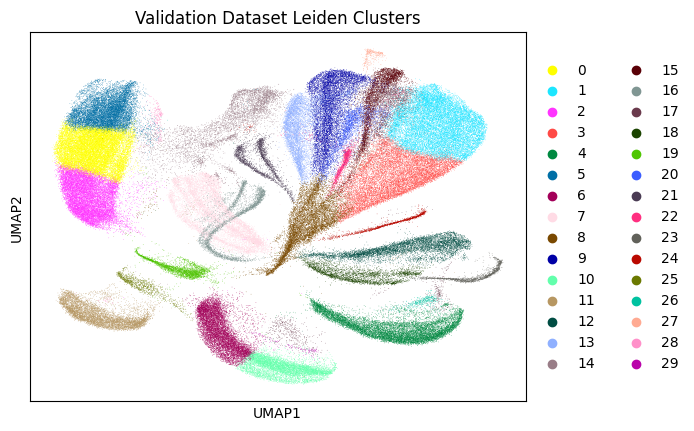

In [2]:
import os
# Define save directory
save_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure8"
os.makedirs(save_dir, exist_ok=True)

import scanpy as sc

adata = sc.AnnData(expr_filtered)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata)

sc.pl.umap(adata, color="leiden", title="Validation Dataset Leiden Clusters", show=False)
plt.savefig(os.path.join(save_dir, "Leiden_umap.png"), dpi=300, bbox_inches='tight')
plt.show()


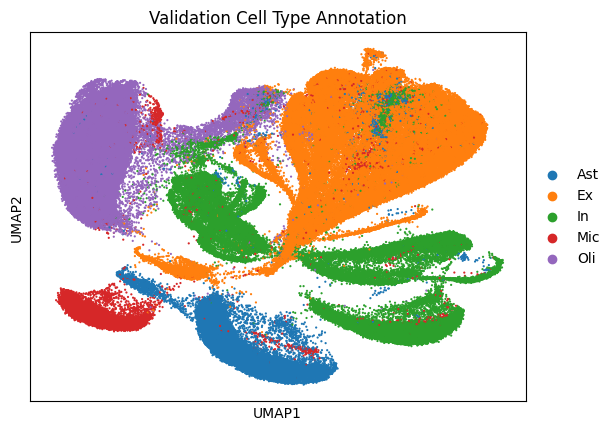

In [3]:
# Match metadata to filtered expression
adata.obs = meta.loc[expr_filtered.index].copy()

# Plot and save UMAP
sc.pl.umap(
    adata,
    color="broad.cell.type",
    size=10,
    title="Validation Cell Type Annotation",
    show=False,
    return_fig=True
)
plt.savefig(os.path.join(save_dir, "Our_celltype_umap.png"), dpi=300, bbox_inches='tight')
plt.show()

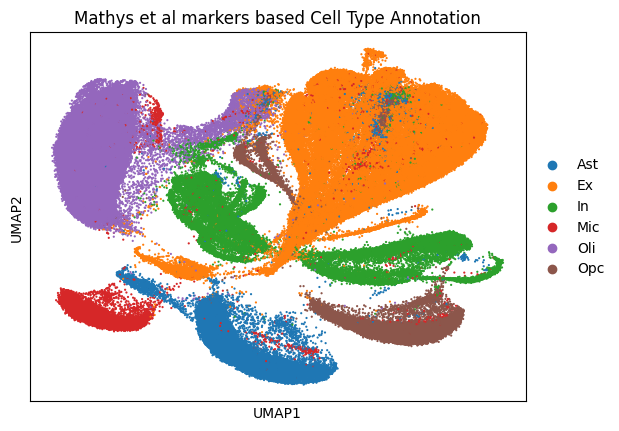

In [4]:
# Load new metadata with Mathys_cell_type
metadata = pd.read_parquet("/n/groups/patel/adithya/Validation_Metadata_Final_checked.parquet")
metadata = metadata.set_index("TAG")

# Add Mathys_cell_type to adata.obs
adata.obs["Mathys_cell_type"] = metadata.loc[adata.obs_names, "Mathys_cell_type"]

# Plot and save UMAP
sc.pl.umap(
    adata,
    color="Mathys_cell_type",
    size=10,
    title="Mathys et al markers based Cell Type Annotation",
    show=False,
    return_fig=True
)
plt.savefig(os.path.join(save_dir, "mathys_celltype_umap.png"), dpi=300, bbox_inches='tight')
plt.show()

In [5]:
sc.tl.leiden(adata)
pd.crosstab(adata.obs['leiden'], adata.obs['broad.cell.type'])

broad.cell.type,Ast,Ex,In,Mic,Oli
leiden,,,,,
0,23,0,5,26,16527
1,59,14431,164,134,12
2,27,15,42,75,13098
3,38,11446,87,36,34
4,24,1,10819,116,1
5,11,0,2,33,10200
6,9423,13,3,26,5
7,56,20,8600,50,9
8,41,8235,149,56,86


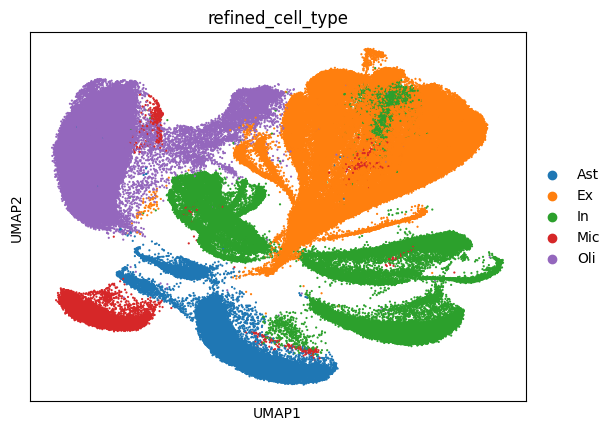

In [6]:
cluster_to_label = {
    '0': 'Oli', '1': 'Ex', '2': 'Oli', '3': 'Ex',
    '4': 'In', '5': 'Oli', '6': 'Ast', '7': 'In',
    '8': 'Ex', '9': 'Ex', '10': 'Ast', '11': 'Mic',
    '12': 'In', '13': 'Ex', '14': 'Oli', '15': 'Ex',
    '16': 'In', '17': 'In', '18': 'In', '19': 'Ast',
    '20': 'Ex', '21': 'Ex', '22': 'Ex', '23': 'In',
    '24': 'Ex', '25': 'Ast', '26': 'In', '27': 'Ex',
    '28': 'Mic', '29': 'Mic'
}

adata.obs["refined_cell_type"] = adata.obs["leiden"].map(cluster_to_label)
sc.pl.umap(adata, color="refined_cell_type", size=10)

In [1]:
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import os

# --- Setup ---
expr = pd.read_parquet('/home/adm808/NormalizedCellMatrixSyn18485175.parquet').T
metadata = pd.read_parquet('/home/adm808/New_CellMetadataSyn1848517.parquet')

# Align metadata and expression
metadata = metadata[metadata['TAG'].isin(expr.index)].set_index('TAG')
expr = expr.loc[metadata.index]

# Create AnnData object
adata = sc.AnnData(expr)
adata.obs = metadata.copy()

# UMAP and clustering
sc.pp.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5)

# Output directory
save_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure8"
os.makedirs(save_dir, exist_ok=True)

# --- Plot 1: Leiden Clustering ---
fig1 = sc.pl.umap(
    adata,
    color="leiden",
    title="Leiden Clusters for Mathys Dataset",
    show=False,
    return_fig=True
)
fig1.savefig(os.path.join(save_dir, "Mathys_umap_leiden.png"), dpi=300, bbox_inches='tight')
plt.close(fig1)

# --- Plot 2: Cell Type Annotation ---
fig2 = sc.pl.umap(
    adata,
    color="broad.cell.type",
    title="Mathys with Cell Type Annotations",
    show=False,
    return_fig=True
)
fig2.savefig(os.path.join(save_dir, "Mathys_umap_broad_cell_type.png"), dpi=300, bbox_inches='tight')
plt.close(fig2)

print("Both UMAP plots saved successfully.")

/tmp/ipykernel_542385/3990598259.py:22: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5)


Both UMAP plots saved successfully.


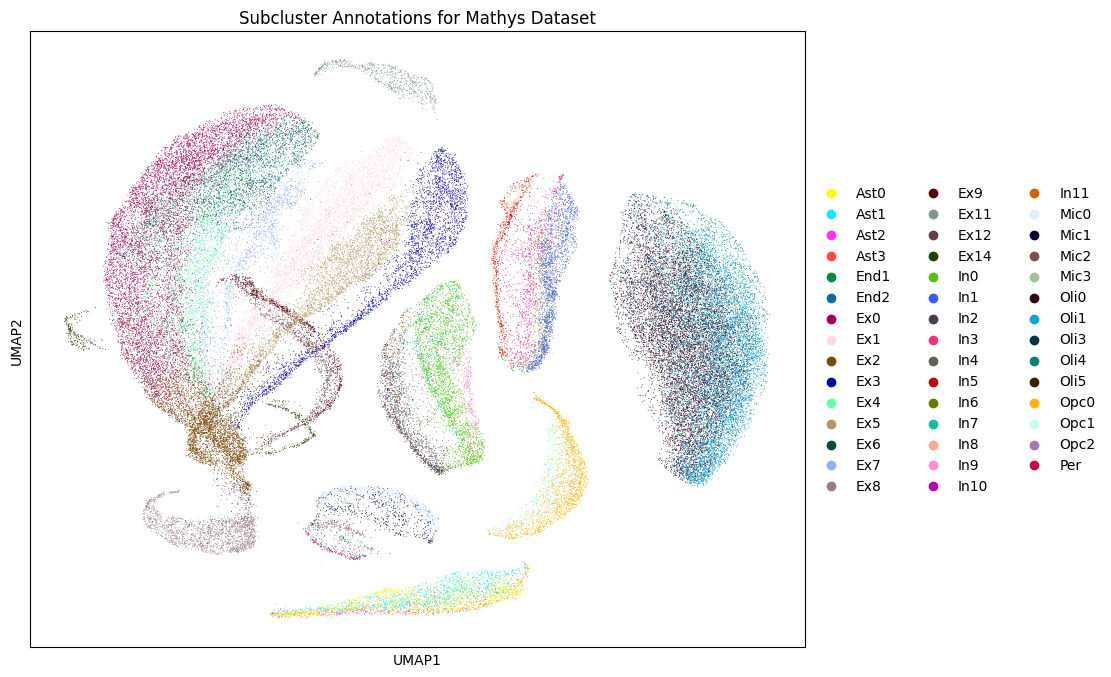

In [2]:
fig = sc.pl.umap(
    adata,
    color=["Subcluster"],
    wspace=0.4,
    title="Subcluster Annotations for Mathys Dataset",
    show=False,
    return_fig=True
)

fig.set_size_inches(10, 8)  # Adjust as needed
fig.savefig(
    "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure8/Mathys_umap_subcluster_leiden.png",
    dpi=300,
    bbox_inches="tight"
)

UMAP plot with Subcluster saved.


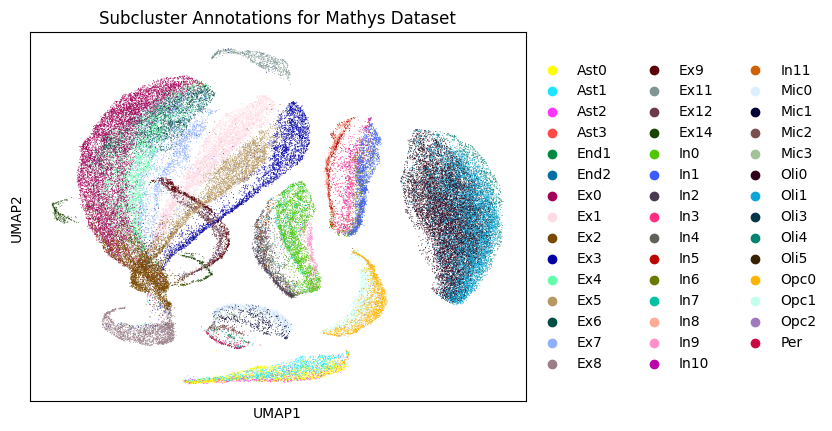

In [8]:
sc.pl.umap(adata, color=["Subcluster"], wspace=0.4, title="Subcluster Annotations for Mathys Dataset", show=False, return_fig=True)
plt.savefig("/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure8/Mathys_umap_subcluster_leiden.png", dpi=300)
print("UMAP plot with Subcluster saved.")

In [9]:
import pandas as pd
metadata = pd.read_parquet('/home/adm808/New_CellMetadataSyn1848517.parquet')
metadata.columns

Index(['TAG', 'projid', 'tsne1', 'tsne2', 'pre.cluster', 'broad.cell.type',
       'Subcluster', 'msex', 'apoe_genotype', 'age_first_ad_dx', 'braaksc',
       'Study', 'educ', 'race', 'spanish', 'age_at_visit_max', 'age_death',
       'cts_mmse30_first_ad_dx', 'cts_mmse30_lv', 'pmi', 'ceradsc', 'cogdx',
       'dcfdx_lv', 'individualID', 'sample'],
      dtype='object')

/tmp/ipykernel_1876604/3965621978.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  individuals["AD_status"] = individuals["dcfdx_lv"].isin([4, 5]).map({True: "AD", False: "Control"})
/tmp/ipykernel_1876604/3965621978.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=individuals, x="AD_status", y="pmi", inner="box", palette="Set2")


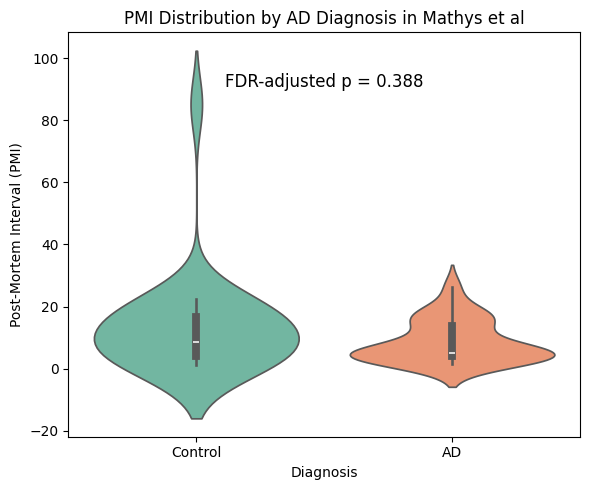

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Load metadata
metadata = pd.read_parquet('/home/adm808/New_CellMetadataSyn1848517.parquet')
metadata = metadata.dropna(subset=["pmi"])

# Select unique individuals to avoid repeated PMI values
individuals = metadata.drop_duplicates(subset="projid")

# Define AD case/control status
individuals["AD_status"] = individuals["dcfdx_lv"].isin([4, 5]).map({True: "AD", False: "Control"})

# Subset PMI values for each group
ad_pmi = individuals[individuals["AD_status"] == "AD"]["pmi"]
control_pmi = individuals[individuals["AD_status"] == "Control"]["pmi"]

# Perform Mann-Whitney U test
stat, p_raw = mannwhitneyu(ad_pmi, control_pmi, alternative='two-sided')

# FDR correction (only 1 test here, but shown for clarity)
_, p_fdr, _, _ = multipletests([p_raw], method='fdr_bh')

# Plot violin plot
plt.figure(figsize=(6, 5))
sns.violinplot(data=individuals, x="AD_status", y="pmi", inner="box", palette="Set2")
plt.title("PMI Distribution by AD Diagnosis in Mathys et al")

# Annotate the corrected p-value
plt.text(0.5, individuals["pmi"].max() * 1.05,
         f"FDR-adjusted p = {p_fdr[0]:.3g}",
         ha='center', va='bottom', fontsize=12)

plt.xlabel("Diagnosis")
plt.ylabel("Post-Mortem Interval (PMI)")
plt.tight_layout()
plt.savefig("/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure8/Mathys_pmi", dpi=300)
plt.show()

In [11]:

meta.columns

Index(['sample', 'diagnosis', 'ID', 'CONDITION', 'AGE', 'SEX', 'PMD',
       'HIST DIAGNOSIS', 'DIAG 1', 'DIAG 2', 'DIAG 3',
       'AGE-RELATED PLAQUE SCORE', 'Braak tangle stage', 'APOE',
       'predicted_cell_type', 'broad.cell.type', 'pmi', 'educ',
       'cts_mmse30_lv', 'age_death', 'apoe_genotype', 'alzheimers_or_control',
       'msex', 'pmi_bin', 'predicted_subcluster'],
      dtype='object')

In [12]:
meta.head()

,sample,diagnosis,ID,CONDITION,AGE,SEX,PMD,HIST DIAGNOSIS,DIAG 1,DIAG 2,...,broad.cell.type,pmi,educ,cts_mmse30_lv,age_death,apoe_genotype,alzheimers_or_control,msex,pmi_bin,predicted_subcluster
AAACCCAAGAAACCCG-1,AD10,1,AD10,AD,95,M,27.0,"AD probable, mod CAA, mod small vessel disease",AD,NO,...,Ex,27.0,16,25,95,34.0,1,1,0,Ex2
AAACCCAAGAGAATCT-1,AD2,1,AD2,AD,71,M,14.0,"AD definite, severe CAA",AD,CAA,...,In,14.0,16,25,71,44.0,1,1,0,Ex2
AAACCCAAGCAATAGT-1,AD10,1,AD10,AD,95,M,27.0,"AD probable, mod CAA, mod small vessel disease",AD,NO,...,In,27.0,16,25,95,34.0,1,1,0,Oli5
AAACCCAAGGAGCTGT-1,AD10,1,AD10,AD,95,M,27.0,"AD probable, mod CAA, mod small vessel disease",AD,NO,...,Ex,27.0,16,25,95,34.0,1,1,0,Ex2
AAACCCAAGGTTACCT-1,AD10,1,AD10,AD,95,M,27.0,"AD probable, mod CAA, mod small vessel disease",AD,NO,...,Ex,27.0,16,25,95,34.0,1,1,0,Ex2


/tmp/ipykernel_1876604/3166784018.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  individuals["AD_status"] = individuals["alzheimers_or_control"].map({1: "AD", 0: "Control"})
/tmp/ipykernel_1876604/3166784018.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=individuals, x="AD_status", y="pmi", inner="box", palette="Set2")


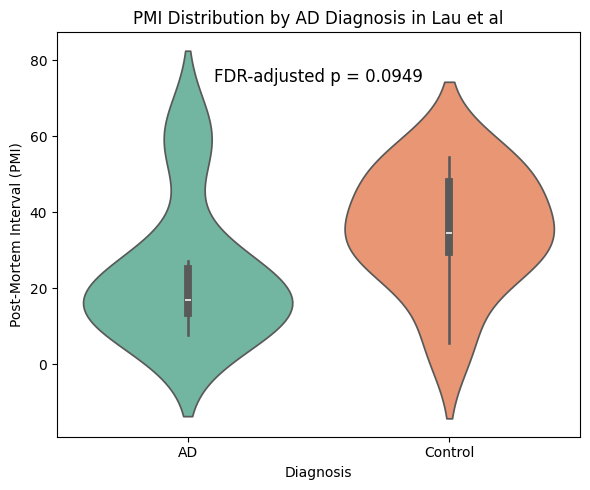

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Load metadata
metadata = pd.read_parquet("/n/groups/patel/adithya/Validation_Metadata_Final.parquet")
metadata = metadata.dropna(subset=["pmi"])

# Select unique individuals to avoid repeated PMI values
individuals = metadata.drop_duplicates(subset="sample")

# Define AD case/control status
individuals["AD_status"] = individuals["alzheimers_or_control"].map({1: "AD", 0: "Control"})

# Subset PMI values for each group
ad_pmi = individuals[individuals["AD_status"] == "AD"]["pmi"]
control_pmi = individuals[individuals["AD_status"] == "Control"]["pmi"]

# Perform Mann-Whitney U test
stat, p_raw = mannwhitneyu(ad_pmi, control_pmi, alternative='two-sided')

# FDR correction (only 1 test here, but shown for clarity)
_, p_fdr, _, _ = multipletests([p_raw], method='fdr_bh')

# Plot violin plot
plt.figure(figsize=(6, 5))
sns.violinplot(data=individuals, x="AD_status", y="pmi", inner="box", palette="Set2")
plt.title("PMI Distribution by AD Diagnosis in Lau et al")

# Annotate the corrected p-value
plt.text(0.5, individuals["pmi"].max() * 1.2,
         f"FDR-adjusted p = {p_fdr[0]:.3g}",
         ha='center', va='bottom', fontsize=12)

plt.xlabel("Diagnosis")
plt.ylabel("Post-Mortem Interval (PMI)")
plt.tight_layout()
plt.savefig("/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure8/Lau_pmi", dpi=300)
plt.show()

/tmp/ipykernel_1876604/3550754.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  individuals["cerad_ad"] = individuals["ceradsc"].isin([1, 2]).astype(int)
/tmp/ipykernel_1876604/3550754.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  individuals["dcfdx_ad"] = individuals["dcfdx_lv"].isin([4.0, 5.0]).astype(int)


          cerad_label        dcfdx_label  count
0  Pathology: Control  Clinical: Control     20
1  Pathology: Control       Clinical: AD      4
2       Pathology: AD  Clinical: Control      6
3       Pathology: AD       Clinical: AD     18


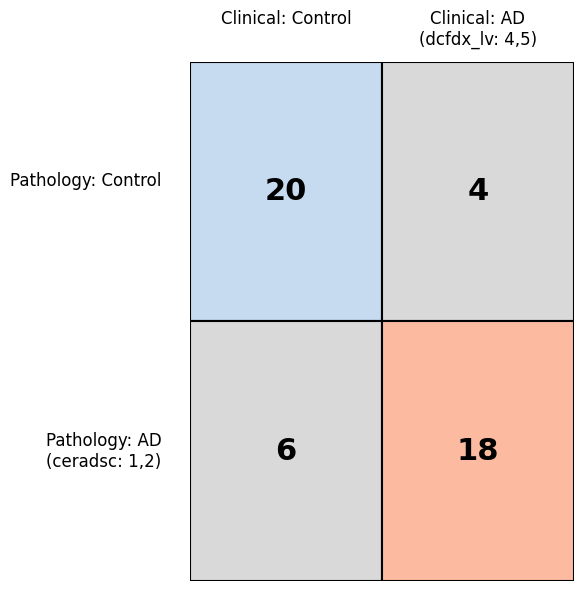

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Load metadata and collapse to unique individuals
metadata = pd.read_parquet('/home/adm808/New_CellMetadataSyn1848517.parquet')
individuals = metadata.drop_duplicates("projid")

# Define AD status
individuals["cerad_ad"] = individuals["ceradsc"].isin([1, 2]).astype(int)
individuals["dcfdx_ad"] = individuals["dcfdx_lv"].isin([4.0, 5.0]).astype(int)

# Group and label
summary = individuals.groupby(["cerad_ad", "dcfdx_ad"]).size().reset_index(name="count")
summary["cerad_label"] = summary["cerad_ad"].map({0: "Pathology: Control", 1: "Pathology: AD"})
summary["dcfdx_label"] = summary["dcfdx_ad"].map({0: "Clinical: Control", 1: "Clinical: AD"})

print(summary[["cerad_label", "dcfdx_label", "count"]])

# Grid values and labels
labels = [["20", "4"], ["6", "18"]]
row_labels = ["Pathology: Control", "Pathology: AD"]
row_vars = ["", "Moderate or Frequent Neuritic Plaque"]
col_labels = ["Clinical: Control", "Clinical: AD"]
col_vars = ["", "AD Cogntive Impairment"]
colors = [["#c6dbef", "#d9d9d9"], ["#d9d9d9", "#fcbba1"]]

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

# Draw squares and numbers
for i in range(2):
    for j in range(2):
        rect = patches.Rectangle((j, 1 - i), 1, 1, linewidth=1.5, edgecolor='black', facecolor=colors[i][j])
        ax.add_patch(rect)
        ax.text(j + 0.5, 1 - i + 0.5, labels[i][j],
                va='center', ha='center', fontsize=22, fontweight='bold', color='black')

# Add row labels with variable
for i, row_label in enumerate(row_labels):
    ax.text(-0.15, 1 - i + 0.5, f"{row_label}\n{row_vars[i]}", va='center', ha='right', fontsize=12)

# Add column labels with variable
for j, col_label in enumerate(col_labels):
    ax.text(j + 0.5, 2.05, f"{col_label}\n{col_vars[j]}", va='bottom', ha='center', fontsize=12)

# Style
ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([])
ax.set_yticks([])
ax.axis("off")

plt.tight_layout()
plt.savefig("figure1b_ad_labels_grid.png", dpi=600, bbox_inches='tight')
plt.show()

In [84]:
import pandas as pd
import numpy as np

# Load the two metadata files
meta1 = pd.read_parquet('/home/adm808/New_CellMetadataSyn1848517.parquet')  # Mathys
meta2 = pd.read_parquet('/n/groups/patel/adithya/Validation_Metadata_Final.parquet')  # Lau

# Normalize key column names
meta1['dataset'] = 'Mathys'
meta2['dataset'] = 'Lau'

meta1['msex'] = meta1['msex'].replace({1.0: 1, 2.0: 0}).astype(int)
meta2['msex'] = meta2['SEX'].map({'M': 1, 'F': 0})
meta2['age_death'] = meta2['AGE']
meta2['dcfdx_lv'] = np.where(meta2['diagnosis'] == 1, 4.0, np.nan)
meta2['dcfdx_lv'] = np.where(meta2['diagnosis'] == 0, 1.0, np.nan)

# Harmonize braak stage
meta1['braak_stage'] = meta1['braaksc']
meta2['braak_stage'] = meta2['Braak tangle stage']

# Harmonize CERAD/age-related plaque score
meta1['ceradsc/age-related_plaque_score'] = meta1['ceradsc']
meta2['ceradsc/age-related_plaque_score'] = meta2['AGE-RELATED PLAQUE SCORE']

# Merge APOE genotype columns
numeric_to_string = {
    22.0: 'E2/E2',
    23.0: 'E2/E3',
    24.0: 'E2/E4',
    33.0: 'E3/E3',
    34.0: 'E3/E4',
    44.0: 'E4/E4'
}
meta1['apoe_genotype'] = pd.to_numeric(meta1['apoe_genotype'], errors='coerce')
meta2['apoe_genotype'] = pd.to_numeric(meta2['apoe_genotype'], errors='coerce')
meta1['apoe_genotype'] = meta1['apoe_genotype'].map(numeric_to_string)
meta2['apoe_genotype'] = meta2['apoe_genotype'].map(numeric_to_string)

# Include only Mathys education and PMI; leave as Na for Lau
meta2['educ'] = np.nan
meta1['pmi'] = meta1['pmi']
meta2['pmi'] = meta2['pmi']

# Concatenate metadata
metadata = pd.concat([meta1, meta2], axis=0, ignore_index=True)

# Filter down to only cells with valid sample and broad.cell.type
metadata = metadata.dropna(subset=['sample', 'broad.cell.type'])

# Keep only relevant cell types
cell_types = ['Mic', 'Ast', 'Opc', 'In', 'Ex', 'Oli']
metadata = metadata[metadata['broad.cell.type'].isin(cell_types)]

# Calculate percentage of each of the 6 cell types per sample
cell_counts = metadata.groupby(['sample', 'broad.cell.type']).size().unstack(fill_value=0)
cell_percents = cell_counts.div(cell_counts.sum(axis=1), axis=0) * 100
cell_percents = cell_percents[cell_types]  # Ensure consistent column order

# Merge back with sample-level metadata
sample_cols = ['sample', 'age_death', 'msex', 'apoe_genotype', 'educ', 'pmi', 'dataset', 'ceradsc/age-related_plaque_score', 'dcfdx_lv', 'braak_stage']
sample_metadata = metadata.drop_duplicates(subset=['sample'])[sample_cols].set_index('sample')
merged = sample_metadata.join(cell_percents, how='left')


# Add diagnosis column: AD if dcfdx_lv is 4 or 5, else Control
# Reset index first so 'sample' is a column again
merged = merged.reset_index()
merged['cell_counts'] = merged['sample'].map(metadata['sample'].value_counts())
dcfdx_map = metadata.drop_duplicates(subset='sample').set_index('sample')['dcfdx_lv']
merged['dcfdx_lv'] = merged['sample'].map(dcfdx_map)
merged['diagnosis'] = np.where(merged['dcfdx_lv'].isin([4.0, 5.0]), 'AD', 'Control')

# Drop any duplicate sample rows (keep first)
merged = merged[~merged.index.duplicated(keep='first')]
merged = merged.rename(columns={ct: f"{ct} (%)" for ct in cell_types})



# Final result
merged = merged.reset_index()
merged = merged.drop(columns='index', errors='ignore')
merged.columns.name = None
merged.head()
merged.to_csv("/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Data/Full_Experiment_Metadata.csv", index=False)

: 

: 

: 

Raw Number of Cells per Cell Type per Dataset:

          Mic    Ast   Opc     In     Ex    Oli
dataset                                        
Lau      8357  19660     0  37244  63499  43754
Mathys   1920   3392  2627   9196  34976  18235


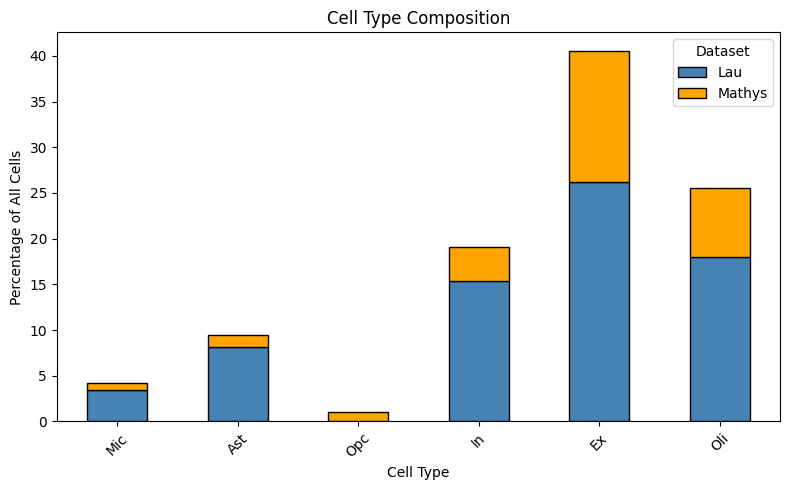

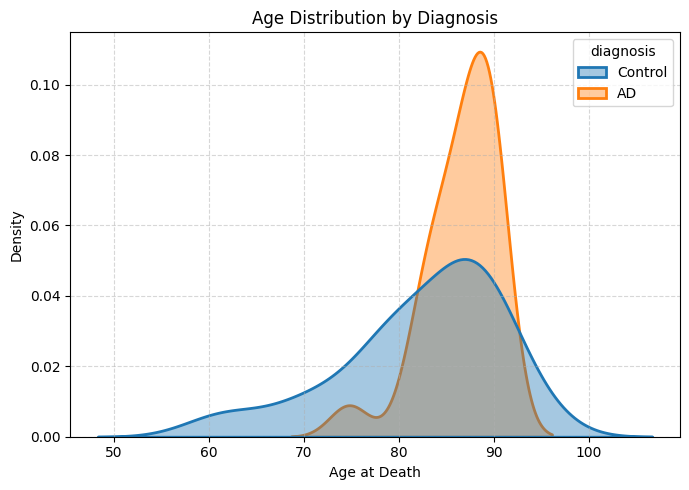

: 

: 

: 

In [87]:
# First, make sure the per-cell-type counts are computed
cell_types = ['Mic', 'Ast', 'Opc', 'In', 'Ex', 'Oli']
for ct in cell_types:
    merged[f"{ct}_n"] = merged['cell_counts'] * merged[f"{ct} (%)"] / 100

# Group by dataset and sum the estimated number of cells
summary_table = (
    merged.groupby('dataset')[[f"{ct}_n" for ct in cell_types]]
    .sum()
    .round(0)  # round to nearest whole number
    .astype(int)  # convert to int for cleaner display
)

# Rename columns to remove "_n" suffix for display
summary_table.columns = [ct for ct in cell_types]

# Display table
print("Raw Number of Cells per Cell Type per Dataset:\n")
print(summary_table)


import matplotlib.pyplot as plt

# Use the same summary table
summary_table = (
    merged.groupby('dataset')[[f"{ct}_n" for ct in cell_types]]
    .sum()
)
summary_table.columns = cell_types  # remove "_n"

# Compute percentages
dataset_percents = 100 * summary_table / summary_table.values.sum()

# Plot
ax = dataset_percents.T.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5),
    color={'Mathys': 'orange', 'Lau': 'steelblue'},
    edgecolor='black'
)

ax.set_ylabel('Percentage of All Cells')
ax.set_xlabel('Cell Type')
ax.set_title('Cell Type Composition')
ax.legend(title='Dataset')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure8/cell_type_dataset_composition_barplot.png", dpi=300)
plt.show()

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Replace "90+" with "90"
merged['age_death'] = merged['age_death'].replace("90+", "90")

# Step 2: Convert to numeric
merged['age_death'] = pd.to_numeric(merged['age_death'], errors='coerce')

# Step 3: Drop rows with missing age or diagnosis
plot_data = merged.dropna(subset=['age_death', 'diagnosis'])

# Step 4: KDE plot
plt.figure(figsize=(7, 5))
sns.kdeplot(
    data=plot_data,
    x='age_death',
    hue='diagnosis',
    common_norm=False,
    fill=True,
    alpha=0.4,
    linewidth=2
)

plt.xlabel('Age at Death')
plt.ylabel('Density')
plt.title('Age Distribution by Diagnosis')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure8/age_distribution_kde.png", dpi=300)
plt.show()